Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [2]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [3]:
import pandas as pd

In [4]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [5]:
df.shape

(6, 5)

In [6]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [8]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [9]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [10]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [11]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [12]:
import numpy as np
import matplotlib.pyplot as plt

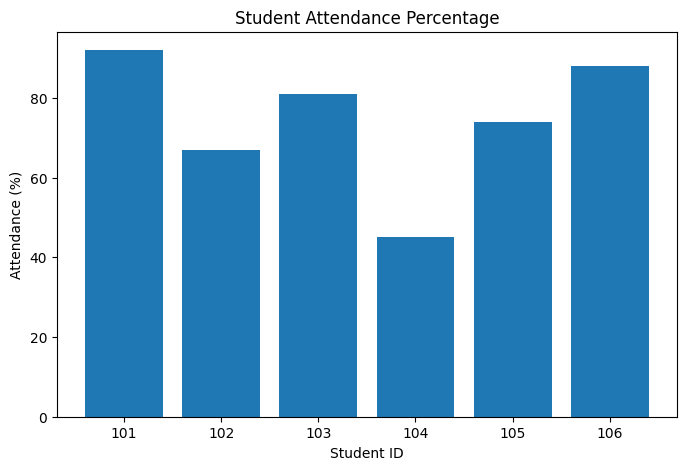

In [13]:
# Vizualizaion for attendance
plt.figure(figsize=(8,5))
plt.bar(df["student_id"], df["attendance_percent"])
plt.title("Student Attendance Percentage")
plt.xlabel("Student ID")
plt.ylabel("Attendance (%)")
plt.show()

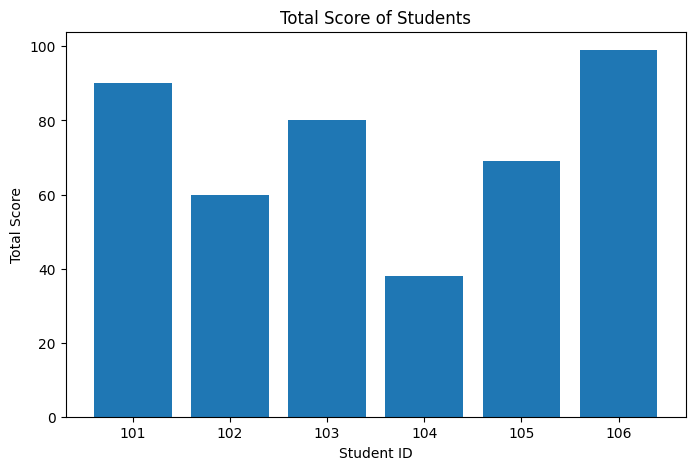

In [14]:
# Total Score Visualization
plt.figure(figsize=(8,5))
plt.bar(df["student_id"], df["total_score"])
plt.title("Total Score of Students")
plt.xlabel("Student ID")
plt.ylabel("Total Score")
plt.show()

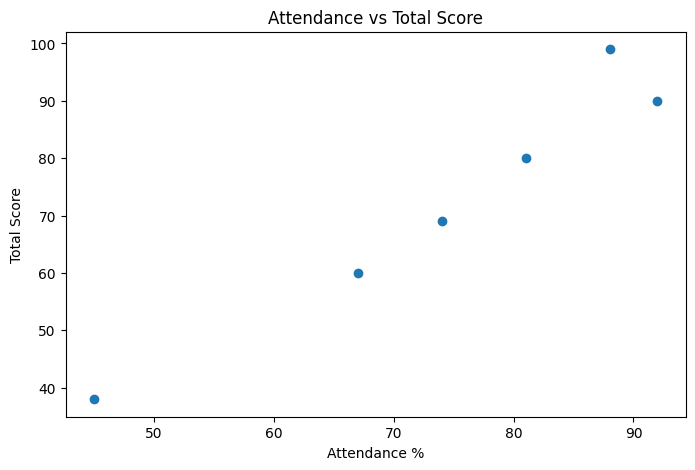

In [15]:
# Vizualization for Attendance VS Total Score
plt.figure(figsize=(8,5))
plt.scatter(
    df["attendance_percent"],
    df["total_score"]
)

plt.xlabel("Attendance %")
plt.ylabel("Total Score")
plt.title("Attendance vs Total Score")
plt.show()

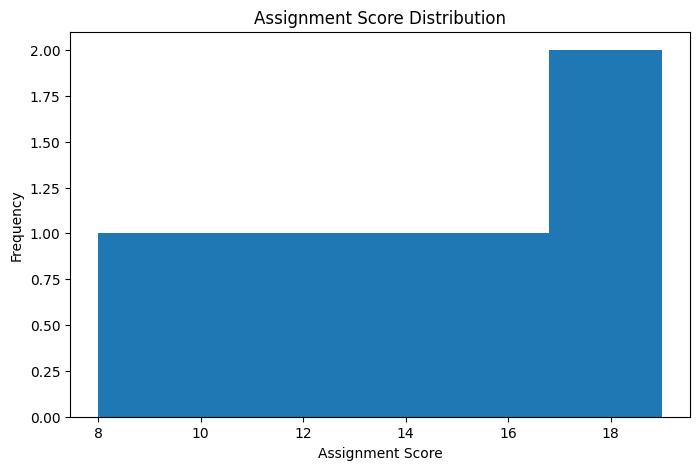

In [16]:
# Assignment Score Distribution
plt.figure(figsize=(8,5))
plt.hist(df["assignment_score"], bins=5)

plt.title("Assignment Score Distribution")
plt.xlabel("Assignment Score")
plt.ylabel("Frequency")
plt.show()

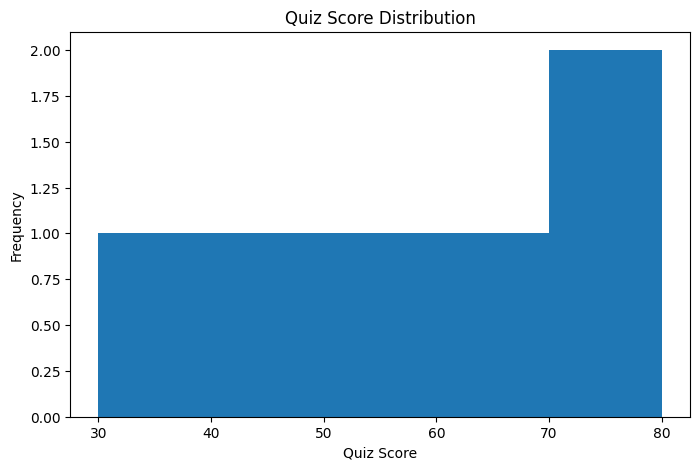

In [17]:
# Quiz Score Distribution
plt.figure(figsize=(8,5))
plt.hist(df["quiz_score"], bins=5)

plt.title("Quiz Score Distribution")
plt.xlabel("Quiz Score")
plt.ylabel("Frequency")
plt.show()

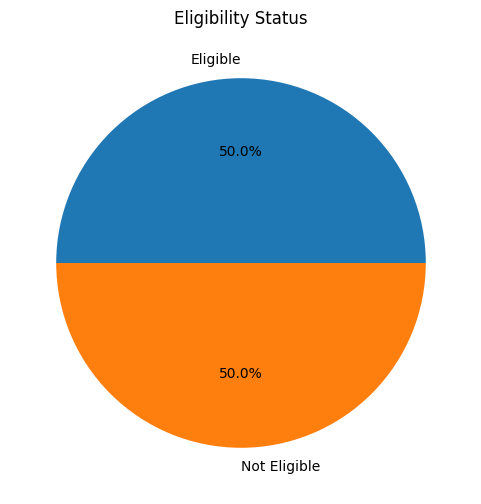

In [18]:
# Eligibility Count Vizualization
eligible_counts = df["eligible"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    eligible_counts,
    labels=["Eligible", "Not Eligible"],
    autopct="%1.1f%%"
)

plt.title("Eligibility Status")
plt.show()

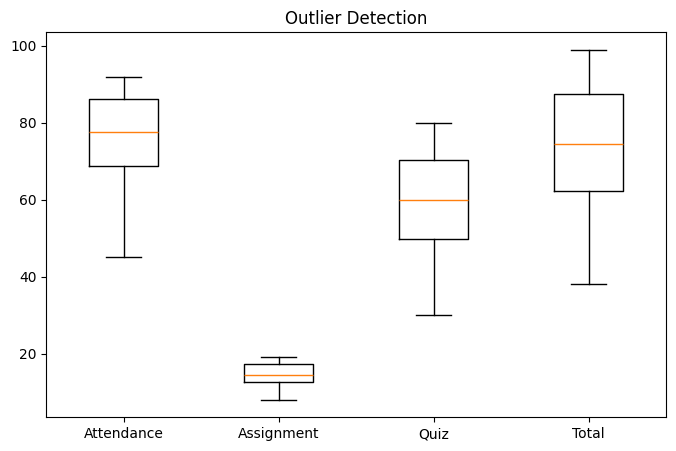

In [21]:
# Boxplot for Outlier Detection Vizualization
plt.figure(figsize=(8,5))
plt.boxplot([
    df["attendance_percent"],
    df["assignment_score"],
    df["quiz_score"],
    df["total_score"]
])

plt.xticks(
    [1,2,3,4],
    ["Attendance","Assignment","Quiz","Total"]
)

plt.title("Outlier Detection")
plt.show()

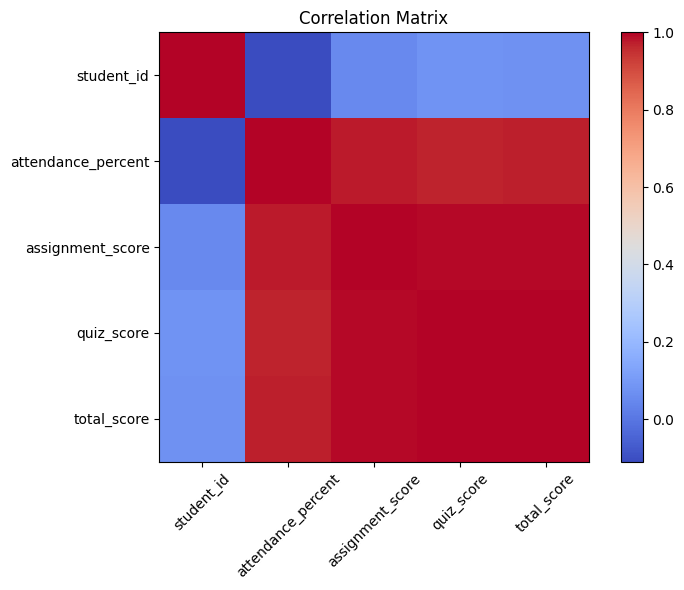

In [22]:
# Correlation Heatmap (Pure Matplotlib)
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

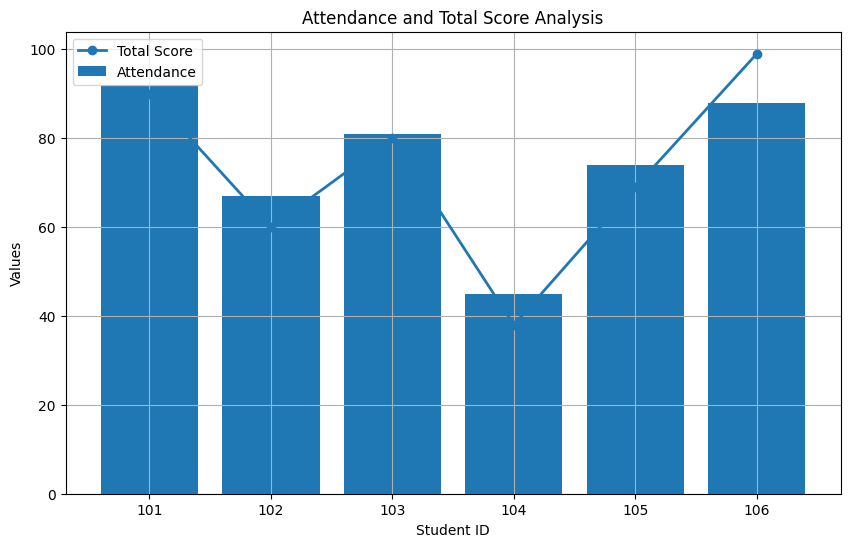

In [23]:
# Top Professional Visualization (Recommended)
plt.figure(figsize=(10,6))

plt.bar(
    df["student_id"],
    df["attendance_percent"],
    label="Attendance"
)

plt.plot(
    df["student_id"],
    df["total_score"],
    marker="o",
    linewidth=2,
    label="Total Score"
)

plt.title("Attendance and Total Score Analysis")
plt.xlabel("Student ID")
plt.ylabel("Values")
plt.legend()
plt.grid(True)

plt.show()

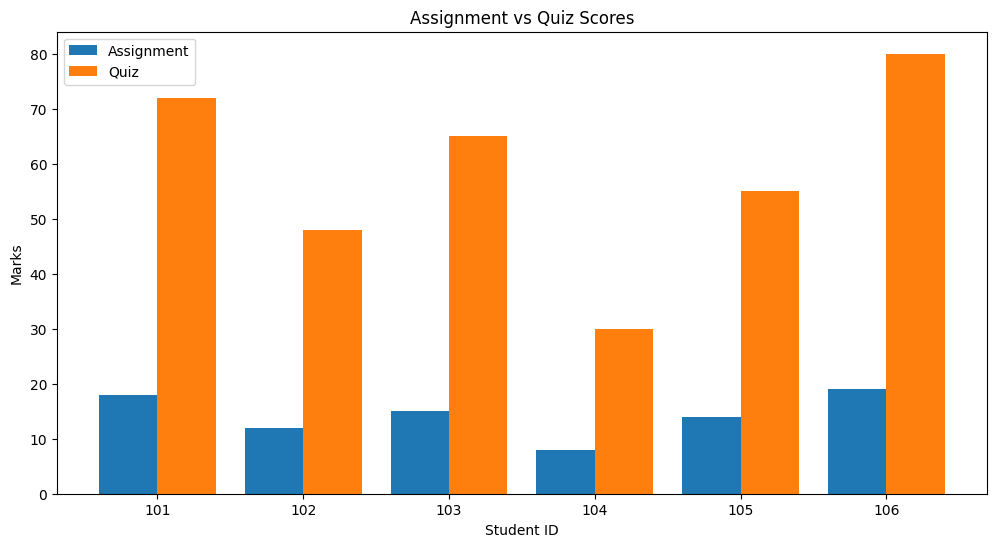

In [28]:
# Assignment vs Quiz Score Vizualization
x = range(len(df))

plt.figure(figsize=(12,6))

plt.bar(
    [i-0.2 for i in x],
    df['assignment_score'],
    width=0.4,
    label='Assignment'
)

plt.bar(
    [i+0.2 for i in x],
    df['quiz_score'],
    width=0.4,
    label='Quiz'
)

plt.xticks(x, df['student_id'])

plt.title("Assignment vs Quiz Scores")
plt.xlabel("Student ID")
plt.ylabel("Marks")
plt.legend()
plt.show()

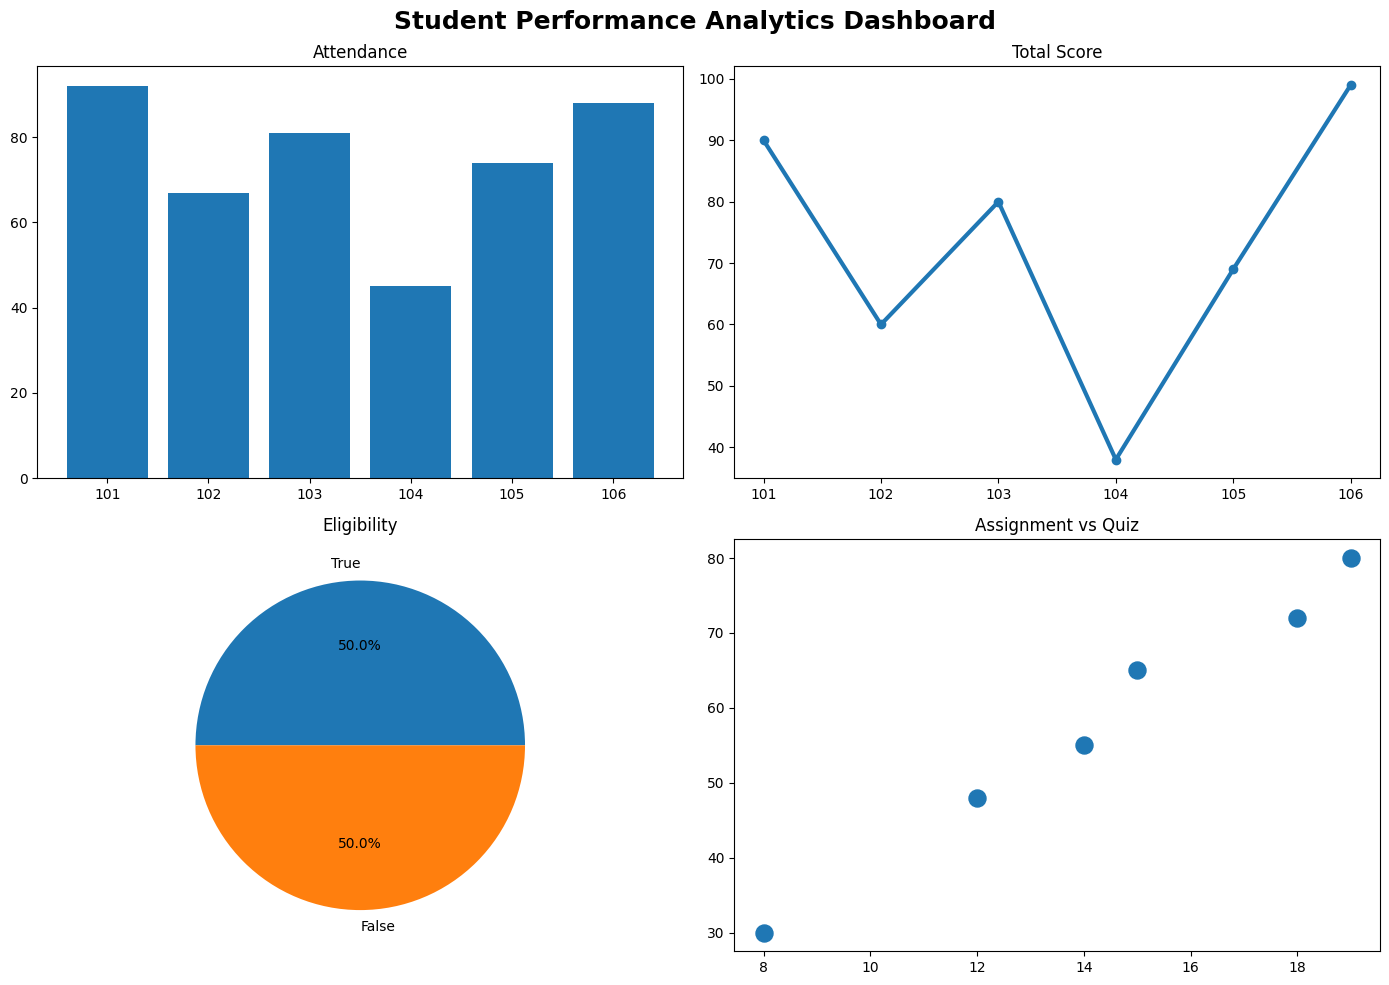

In [24]:
# Top Attractive Dashboard (Professor-Impressing Visualization)
fig = plt.figure(figsize=(14,10))

# Attendance
plt.subplot(2,2,1)
plt.bar(df['student_id'], df['attendance_percent'])
plt.title("Attendance")

# Total Score
plt.subplot(2,2,2)
plt.plot(df['student_id'],
         df['total_score'],
         marker='o',
         linewidth=3)
plt.title("Total Score")

# Eligibility
plt.subplot(2,2,3)
df['eligible'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title("Eligibility")

# Assignment vs Quiz
plt.subplot(2,2,4)
plt.scatter(
    df['assignment_score'],
    df['quiz_score'],
    s=150
)
plt.title("Assignment vs Quiz")

plt.suptitle(
    "Student Performance Analytics Dashboard",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()